In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import tensorflow as tf
import keras
from keras.layers import Dense, Conv2D, Flatten, Dropout, MaxPooling2D, BatchNormalization
from keras.models import Sequential, Model
from keras.optimizers import RMSprop
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input

# **Part 1: Preprocessing**

In [22]:
# Load CIFAR-10 dataset
(train_data, train_labels), (test_data, test_labels) = tf.keras.datasets.cifar10.load_data()

train_data = train_data / 255.0
test_data = test_data / 255.0

# Augment training dataset
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    rescale=1./255.0  # Normalize pixel values to between 0 and 1
)
train_set = train_datagen.flow(train_data, train_labels, batch_size=64)

# Prepare test dataset
test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255.0)
test_set = test_datagen.flow(test_data, test_labels, batch_size=64)

print("Number of Training Samples:", train_set.n)
print("Number of Test Samples:", test_set.n)

# Number of unique classes
num_classes = len(np.unique(train_labels))

print("Number of Classes:", num_classes)

# CIFAR-10 class names
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Extract unique labels from the training set
unique_labels = set(train_labels.flatten())

# Print class labels
print("Class Labels:")
for label in sorted(unique_labels):
    print(f"{label}: {class_names[label]}")



Number of Training Samples: 50000
Number of Test Samples: 10000
Number of Classes: 10
Class Labels:
0: airplane
1: automobile
2: bird
3: cat
4: deer
5: dog
6: frog
7: horse
8: ship
9: truck


# **Part 2: Model Architecture**

In [23]:
# Define the CNN architecture
model = tf.keras.Sequential([
    # Convolutional layers
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),

    # Flatten layer
    tf.keras.layers.Flatten(),

    # Fully connected layers
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')  # 10 output classes for CIFAR-10
])

# Print model summary
model.summary()


Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_9 (Conv2D)           (None, 30, 30, 32)        896       
                                                                 
 max_pooling2d_6 (MaxPoolin  (None, 15, 15, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_10 (Conv2D)          (None, 13, 13, 64)        18496     
                                                                 
 max_pooling2d_7 (MaxPoolin  (None, 6, 6, 64)          0         
 g2D)                                                            
                                                                 
 conv2d_11 (Conv2D)          (None, 4, 4, 128)         73856     
                                                                 
 flatten_3 (Flatten)         (None, 2048)             

 **Defining Model**

Sequential model

Three convolutional layers with ReLU activation. The first layer receives input images of size (32, 32, 3)

The output sizes of these layers depend on the filter sizes, strides, and padding, but typically reduce the spatial dimensions

Max-pooling layers between the convolutional layers downsample the feature maps

Flatten layer is used to flatten the feature maps into a vector

Fully connected layers with relu activation dense layer followed by a final dense layer with softmax activation

Softmax used for multi-class classification

The output size of the last fully connected layer matches the number of classes in the classification task so that we can produce a 1D array of probabilities than an image belongs to a specific class, with the highest probability being the returned class


\\

Input layer: Input size is (32, 32, 3) for 32x32 image and 3 RGB channels

Convolutional layer 1:
Number of filters: 32
Filter size: (3, 3)
Activation function: relu


MaxPooling layer 1:
Pool size: (2, 2)
Output size: Halves the spatial dimensions

Convolutional layer 2:
Number of filters: 64
Filter size: (3, 3)
Activation function: relu

MaxPooling layer 2:
Pool size: (2, 2)
Output size: Halves the spatial dimensions

Convolutional layer 3:
Number of filters: 128
Filter size: (3, 3)
Activation function: relu

Flatten layer: Flattens the feature maps into a vector

Dense layer 1:
Number of neurons: 128
Activation function: relu

Dense layer 2 (Output layer):
Number of neurons: 10 to match CIFAR-10 labels
Activation function: Softmax

 **Tuning Hyperparameters**




In [ ]:
# Define hyperparameters to tune
learning_rates = [0.001, 0.01]
batch_sizes = [32, 64]
optimizers = ['adam', 'rmsprop']

# Initialize variables to store best hyperparameters and accuracy
best_accuracy = 0.0
best_hyperparameters = {}

# Iterate over hyperparameter combinations
for lr in learning_rates:
    for batch_size in batch_sizes:
        for optimizer in optimizers:
            print(f"Training model with learning rate: {lr}, batch size: {batch_size}, optimizer: {optimizer}")

            # Compile the model with current optimizer
            model.compile(optimizer=optimizer,
                          loss='sparse_categorical_crossentropy',
                          metrics=['accuracy'])

            # Train the model
            history = model.fit(train_data, train_labels, epochs=5, batch_size=batch_size, validation_split=0.2)

            # Evaluate the model on test data
            _, test_accuracy = model.evaluate(test_data, test_labels)

            # Print test accuracy
            print(f"Test accuracy: {test_accuracy}")

            # Update best hyperparameters if current model performs better
            if test_accuracy > best_accuracy:
                best_accuracy = test_accuracy
                best_hyperparameters = {'learning_rate': lr, 'batch_size': batch_size, 'optimizer': optimizer}

# Print best hyperparameters and accuracy
print(f"Best hyperparameters: {best_hyperparameters}")
print(f"Best accuracy: {best_accuracy}")


Training model with learning rate: 0.001, batch size: 32, optimizer: adam
Epoch 1/5
1250/1250 [==============================] - 57s 45ms/step - loss: 0.3491 - accuracy: 0.8774 - val_loss: 1.0498 - val_accuracy: 0.7039
Epoch 2/5
1250/1250 [==============================] - 57s 46ms/step - loss: 0.2945 - accuracy: 0.8951 - val_loss: 1.1541 - val_accuracy: 0.7019
Epoch 3/5
1250/1250 [==============================] - 57s 46ms/step - loss: 0.2503 - accuracy: 0.9116 - val_loss: 1.2824 - val_accuracy: 0.7018
Epoch 4/5
1250/1250 [==============================] - 56s 44ms/step - loss: 0.2159 - accuracy: 0.9234 - val_loss: 1.3938 - val_accuracy: 0.6799
Epoch 5/5
313/313 [==============================] - 4s 14ms/step - loss: 1.4562 - accuracy: 0.6891
Test accuracy: 0.6891000270843506
Training model with learning rate: 0.001, batch size: 32, optimizer: rmsprop
Epoch 1/5
1250/1250 [==============================] - 57s 45ms/step - loss: 0.1591 - accuracy: 0.9449 - val_loss: 1.7802 - val_accurac

# **Part 3: Training**


In [14]:
# Split the dataset into training, validation, and test sets
train_data, test_data, train_labels, test_labels = train_test_split(train_data, train_labels, test_size=0.1, random_state=10)
train_data, val_data, train_labels, val_labels = train_test_split(train_data, train_labels, test_size=0.1111, random_state=10)

print("Number of Training Samples:", train_data.shape[0])
print("Number of Validation Samples:", val_data.shape[0])
print("Number of Test Samples:", test_data.shape[0])



# New CNN model architecture with batch normalization and dropout
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),  # Dropout layer to prevent overfitting
    tf.keras.layers.Dense(10, activation='softmax')
])

Number of Training Samples: 40000
Number of Validation Samples: 5000
Number of Test Samples: 5000


In [15]:
# Compile the model
optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.01)
model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Define early stopping callback for early stopping to prevent overfitting
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(train_data, train_labels, epochs=30, batch_size=64,
                    validation_data=(val_data, val_labels), callbacks=[early_stopping])

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(test_data, test_labels)
print(f'Test Loss: {test_loss}, Test Accuracy: {test_accuracy}')

# Save the best performing model checkpoint
model.save('best_model')


Epoch 1/30
625/625 [==============================] - 63s 100ms/step - loss: 2.5394 - accuracy: 0.1719 - val_loss: 1.9954 - val_accuracy: 0.2362
Epoch 2/30
625/625 [==============================] - 63s 101ms/step - loss: 1.8909 - accuracy: 0.2837 - val_loss: 1.5645 - val_accuracy: 0.4516
Epoch 3/30
625/625 [==============================] - 66s 105ms/step - loss: 1.6125 - accuracy: 0.4270 - val_loss: 2.1220 - val_accuracy: 0.3954
Epoch 4/30
625/625 [==============================] - 61s 97ms/step - loss: 1.5357 - accuracy: 0.4677 - val_loss: 1.3998 - val_accuracy: 0.5358
Epoch 5/30
625/625 [==============================] - 60s 96ms/step - loss: 1.5187 - accuracy: 0.4761 - val_loss: 1.8517 - val_accuracy: 0.4068
Epoch 6/30
625/625 [==============================] - 63s 101ms/step - loss: 1.5226 - accuracy: 0.4791 - val_loss: 1.8194 - val_accuracy: 0.4942
Epoch 7/30
625/625 [==============================] - 60s 96ms/step - loss: 1.5266 - accuracy: 0.4780 - val_loss: 1.4061 - val_accur

# **Part 4: Evalutation**

157/157 [==============================] - 6s 39ms/step - loss: 1.3383 - accuracy: 0.5256
Validation Loss: 1.33826744556427, Validation Accuracy: 0.525600016117096
157/157 [==============================] - 6s 34ms/step
Validation Classification Report:
              precision    recall  f1-score   support

    airplane       0.73      0.52      0.60       491
  automobile       0.92      0.42      0.58       506
        bird       0.49      0.28      0.36       502
         cat       0.24      0.70      0.36       501
        deer       0.56      0.43      0.49       542
         dog       0.61      0.28      0.38       469
        frog       0.59      0.73      0.65       489
       horse       0.76      0.53      0.62       503
        ship       0.60      0.79      0.68       507
       truck       0.66      0.57      0.61       490

    accuracy                           0.53      5000
   macro avg       0.61      0.53      0.53      5000
weighted avg       0.61      0.53      0.5

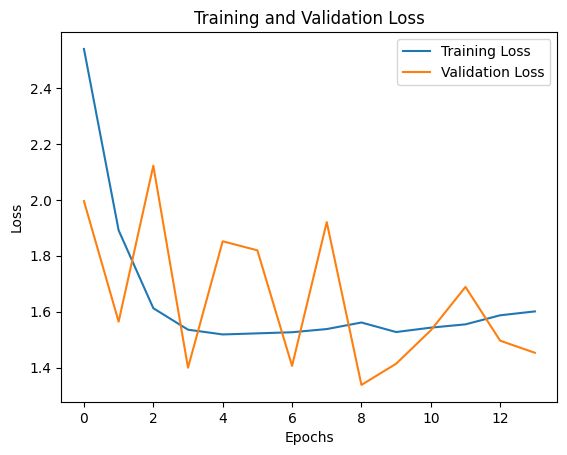

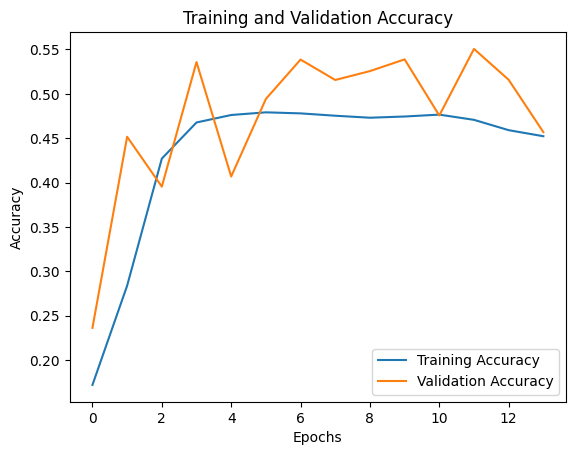

In [16]:
# Evaluate the model on the validation set
val_loss, val_accuracy = model.evaluate(val_data, val_labels)
print(f'Validation Loss: {val_loss}, Validation Accuracy: {val_accuracy}')

# Get predictions on the validation set
val_predictions = np.argmax(model.predict(val_data), axis=1)

# Print classification report for validation set
print("Validation Classification Report:")
print(classification_report(val_labels, val_predictions, target_names=class_names))

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()


157/157 [==============================] - 5s 29ms/step


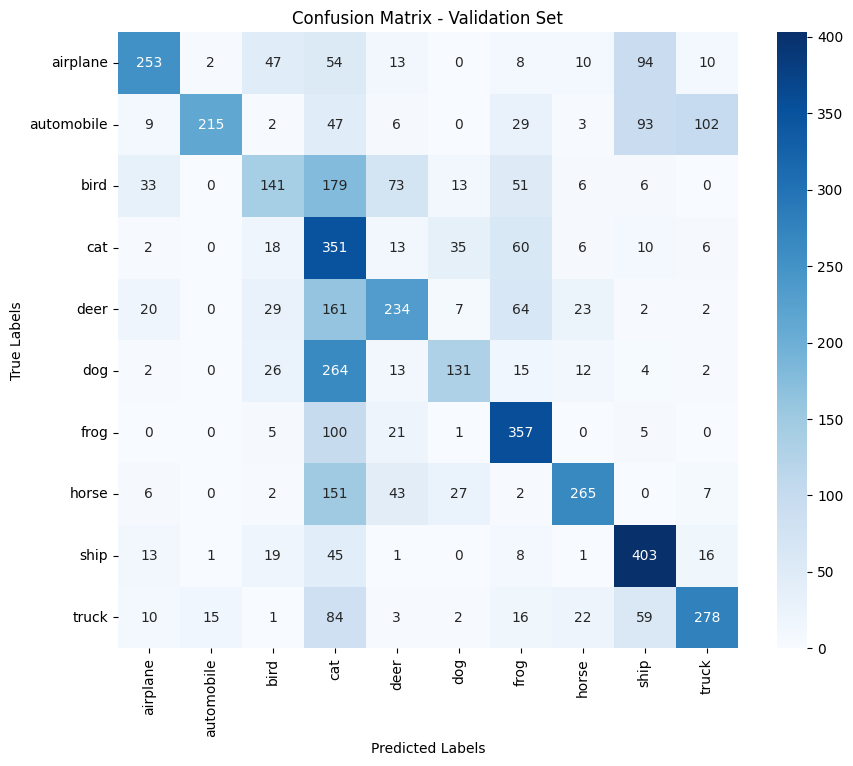

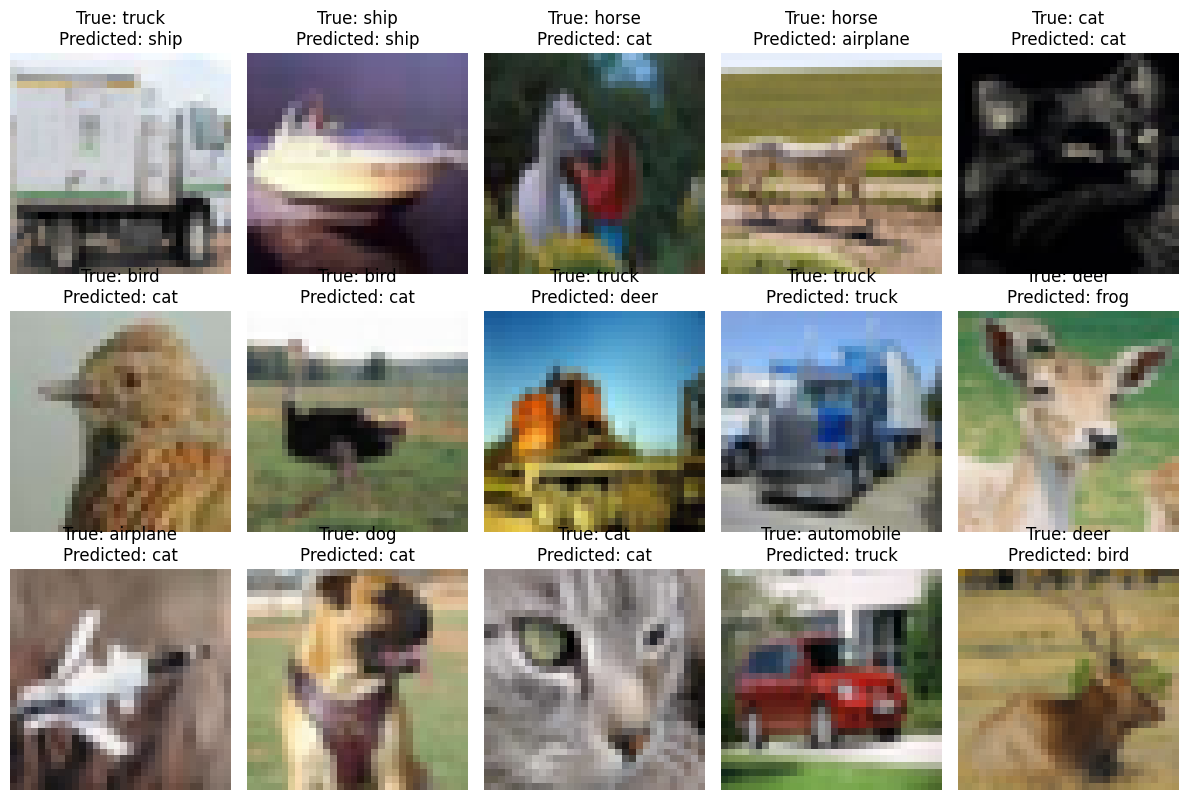

In [18]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
# Get predictions on the validation set
val_predictions = np.argmax(model.predict(val_data), axis=1)

# Compute confusion matrix
conf_matrix = confusion_matrix(val_labels, val_predictions)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - Validation Set')
plt.show()

# Identify misclassified samples
misclassified_idx = np.where(val_labels != val_predictions)[0]

# Randomly select and plot some misclassified samples
plt.figure(figsize=(12, 8))
for i, idx in enumerate(np.random.choice(misclassified_idx, 15, replace=False)):
    plt.subplot(3, 5, i+1)
    plt.imshow(val_data[idx])
    plt.title(f'True: {class_names[val_labels[idx][0]]}\nPredicted: {class_names[val_predictions[idx]]}')
    plt.axis('off')
plt.tight_layout()
plt.show()


# **Part 5: Testing**

In [19]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(test_data, test_labels)
print(f'Final Test Loss: {test_loss}, Final Test Accuracy: {test_accuracy}')


157/157 [==============================] - 3s 15ms/step - loss: 1.3602 - accuracy: 0.5220
Final Test Loss: 1.3601659536361694, Final Test Accuracy: 0.5220000147819519


# **Summary**

In this assignment we designed a CNN for image classification using the CIFAR-10 dataset, which consists of 10 classes of images and 60,000 images. There were instructions for loading the dataset on the website, explaining how to use unpickle but it was simpler to use keras to load the dataset and extract training/test sets.

After preprocessing the data and constructing the CNN, I began with tuning hyperparameters to decide which were best for training the model and having best perfermance on the test data, but the computations were going to take a long time for trying three different learning rates, three different optimizers, and three different batch sizes so i lowered it to two of each category and we could see the best performing parameters were: batch size 64, learning rate 0.01, optimizer rmsprop.

I then split the dataset into training, testing, and validation sets with a split of 40000, 5000, 5000. We define a new CNN model here so that we could implement more parameters like batch normalization to stabilize training and dropout layers to prevent overfitting (these set a percentage of the features to zero during training, while all features are used during testing). I added a stopping callback to prevent overfitting that used a patience of 5 epochs so if loss does not improve within 5 epochs the training will stop and recover the best performance from the respective epoch.

After training, we wished to evaluate the model prior to testing so I evaluated based on validation predictions:

We can gauge performance as follows:
Cat (Class 3):
Precision: 0.24
Recall: 0.70
F1-score: 0.36
Support: 501

Bird (Class 2):
Precision: 0.49
Recall: 0.28
F1-score: 0.36
Support: 502

Deer (Class 4):
Precision: 0.56
Recall: 0.43
F1-score: 0.39
Support: 542

These classes had the lowest performance and were often predicted incorrectly.

Ship (Class 8):
Precision: 0.60
Recall: 0.79
F1-score: 0.68
Support: 507

Frog (Class 6):
Precision: 0.59
Recall: 0.73
F1-score: 0.65
Support: 489

Airplane (Class 0):
Precision: 0.73
Recall: 0.52
F1-score: 0.60
Support: 491

These classes had the highest performance, though some don't have as high precision

On the training and validation loss curve, we can see the training loss consistenly decrease which seems to indicate that the model is learning from the training data. But, the validation loss seems to fluctuate, with many spikes back up after decreasing so this seems to suggest that the model might be overfitting the data or its performance on unseen data may be inconsistent and may require some more fine-tuning.

We can also seem a similar result on the training and validation accuracy curve. We can say the same thing for training accuracy since it increases steadily the model is learning from the training data, but the validation accuracy does fluctuate quite a bit and is pretty inconsistent even though it ends up around where training accuracy is.

The confusion matrix above shows true labels paired with predicted labels so we can view some labels that are often predicted incorrectly and which labels they are mistaken for.

At the end we can visualize some of these predictions to get an idea of what is going on with the model.

I think we could potentially improve the performance of this model by further testing with more parameters and experimenting with the design of the CNN model. I recently worked on a fruit classification model for machine learning class on the fruits-360 dataset so I could try using that model design here since it performed with 87% accuracy on that dataset.